###Meskerem Goshime, Model Deployment
###UT - Post-Graduate Program in Artificial Intelligence and Machine Learning
####March 8, 2026

# **Problem Statement**

## Business Context

A sales forecast is a prediction of future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use the sales forecast to estimate weekly, monthly, quarterly, and annual sales totals. A company needs to make an accurate sales forecast as it adds value across an organization and helps the different verticals to chalk out their future course of action.

Forecasting helps an organization plan its sales operations by region and provides valuable insights to the supply chain team regarding the procurement of goods and materials. An accurate sales forecast process has many benefits which include improved decision-making about the future and reduction of sales pipeline and forecast risks. Moreover, it helps to reduce the time spent in planning territory coverage and establish benchmarks that can be used to assess trends in the future.

## Objective

SuperKart is a retail chain operating supermarkets and food marts across various tier cities, offering a wide range of products. To optimize its inventory management and make informed decisions around regional sales strategies, SuperKart wants to accurately forecast the sales revenue of its outlets for the upcoming quarter.

To operationalize these insights at scale, the company has partnered with a data science firm—not just to build a predictive model based on historical sales data, but to develop and deploy a robust forecasting solution that can be integrated into SuperKart’s decision-making systems and used across its network of stores.

## Data Description

The data contains the different attributes of the various products and stores.The detailed data dictionary is given below.

- **Product_Id** - unique identifier of each product, each identifier having two letters at the beginning followed by a number.
- **Product_Weight** - weight of each product
- **Product_Sugar_Content** - sugar content of each product like low sugar, regular and no sugar
- **Product_Allocated_Area** - ratio of the allocated display area of each product to the total display area of all the products in a store
- **Product_Type** - broad category for each product like meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others
- **Product_MRP** - maximum retail price of each product
- **Store_Id** - unique identifier of each store
- **Store_Establishment_Year** - year in which the store was established
- **Store_Size** - size of the store depending on sq. feet like high, medium and low
- **Store_Location_City_Type** - type of city in which the store is located like Tier 1, Tier 2 and Tier 3. Tier 1 consists of cities where the standard of living is comparatively higher than its Tier 2 and Tier 3 counterparts.
- **Store_Type** - type of store depending on the products that are being sold there like Departmental Store, Supermarket Type 1, Supermarket Type 2 and Food Mart
- **Product_Store_Sales_Total** - total revenue generated by the sale of that particular product in that particular store


# **Installing and Importing the necessary libraries**

In [ ]:
#Installing the libraries with the specified versions

!pip install pandas==2.2.2 numpy==2.0.2 scikit-learn==1.6.1 xgboost==2.1.4 joblib==1.4.2 streamlit==1.43.2 huggingface_hub==0.29.3 -q

**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [ ]:
# for data manipulation
import pandas as pd
import numpy as np

# for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# for data preprocessing and pipeline creation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestRegressor

# for model building, training, tuning, and evaluation
import sklearn
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, recall_score

# for model serialization
import joblib

# for creating a folder
import os

# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi

In [ ]:
# Libraries to get different metric scores
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

In [ ]:
import warnings
warnings.filterwarnings("ignore")

# **Loading the dataset**

In [ ]:
# mounting google drive

from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# loading the data

drive_path = '/content/drive/MyDrive/SuperKart/'
data = pd.read_csv(drive_path + 'SuperKart.csv')
data.head()


# **Data Overview**

In [ ]:
# number columns and rows

data.shape

In [ ]:
# checking for duplicate records

data.duplicated().sum()

In [ ]:
# checking if there are null values

data.isna().sum()

- The data has 8763 records and 12 columns.
- There are no ducplicates and null values in the data.

In [ ]:
# checking column data types

data.dtypes

In [ ]:
# checking the statistical summary for the numerical and categorical columns

data.describe(include='all').T

# **Exploratory Data Analysis (EDA)**

Defining functions to create charts

In [ ]:
# Barplot function with the defalut mean value for the x variable
def barplot(data, x_axis, y_axis, w, h):
  plt.figure(figsize=(w,h))
  ax = sns.barplot(data=data, x=x_axis, y=y_axis, hue=x_axis, legend=False, palette="Paired")
  plt.show()

In [ ]:
# Barplot function showing sum of the x variable
def barplot_sum(data, x_axis, y_axis, w, h):
  plt.figure(figsize=(w,h))
  ax = sns.barplot(data=data, x=x_axis, y=y_axis, hue=x_axis, legend=False, palette="Paired", estimator=np.sum)
  plt.show()


In [ ]:
# Histplot function
def histplot(data, feature, w, h):
  plt.figure(figsize=(w,h))
  sns.histplot(data=data, x=feature, kde=True, palette="Paired")
  plt.show()

In [ ]:
# scatterplot function
def scatterplot(data, x_axis, y_axis, w, h):
    plt.figure(figsize=(w,h))
    sns.scatterplot(x=x_axis, y=y_axis, data=data, palette="Paired")
    plt.show()

In [ ]:
# boxplot function
def boxplot(data, x_axis, y_axis, w, h):
    plt.figure(figsize=(w,h))
    sns.boxplot(x=x_axis, y=y_axis, data=data, hue=x_axis, palette="Paired")
    plt.show()

## Univariate Analysis

In [ ]:
# distribution of the target variable

histplot(data, 'Product_Store_Sales_Total', 5, 2)

In [ ]:
data['Product_Store_Sales_Total'].mean(), data['Product_Store_Sales_Total'].median()

The target variable is normally distributed/not skewed averaging ~$3460.

In [ ]:
# distribution of product weight

histplot(data, 'Product_Weight', 5, 2)

In [ ]:
data['Product_Weight'].mean(), data['Product_Weight'].median()

Product is normally distributed averaging ~13.

In [ ]:
# distribution of product allocated area

histplot(data, 'Product_Allocated_Area', 5, 2)

Product allocated area is right skewed. Most products occupy less than or about 5% of the store area, but there are a few products that take up between 20%-30% of the area.

In [ ]:
# distribution of product maximum retail price

histplot(data, 'Product_MRP', 5, 2)

In [ ]:
data['Product_MRP'].mean(), data['Product_MRP'].median()

Maximum retail price is normally distributed averaging ~$147.

In [ ]:
# distribution of store establishment year

histplot(data, 'Store_Establishment_Year', 5, 2)

In [ ]:
# store establishment year distribution percentages

data.Store_Establishment_Year.value_counts(normalize=True)

- There are only 4 values for store establishment year, 1998, 1999, 1987 and 2009.
- More than 50% of the stores were established in 2009.

## Bivariate Analysis

In [ ]:
# selecting the numeric columns

numeric_cols_df = data.select_dtypes(include=['number'])

numeric_cols_df.columns

In [ ]:
# correlation of the numeric columns

plt.figure(figsize=(5,4))
sns.heatmap(numeric_cols_df.corr(), annot=True, cmap='Paired')

The target variable, Product_Store_Sales_Total is most positively correleted with Product_MRP(0.79) and Product_Weight (0.74).

It makes sense that product with higher maximum retail price bring higher sales total.

In addition maximum retail price is positively correlated with Product_Weight.

In [ ]:
# checking scatter plots of the 3 most correlated columns

sns.pairplot(data[['Product_Weight', 'Product_MRP', 'Product_Store_Sales_Total']])


- Product_Weight, Product_MRP, and Product_Store_Sales_Total are correlated positively.
- products that weigh more tend to have higher maximum retail price and higher sales total.

###Categorical columns relations to the target variable

In [ ]:
boxplot (data, 'Product_Sugar_Content', 'Product_Store_Sales_Total', 4, 4)

In [ ]:
# I am curious to see if sugar content has significant effect on product sales total

boxplot(data, 'Product_Sugar_Content', 'Product_Store_Sales_Total', 4, 4)

In [ ]:
# need to combine reg and Regular categories

data['Product_Sugar_Content'] = data['Product_Sugar_Content'].replace('reg', 'Regular')

In [ ]:
# note - this barplot shows mean of total sales for indivitual products by sugar content

barplot(data, 'Product_Sugar_Content', 'Product_Store_Sales_Total', 3, 2)

In [ ]:
# mean of total sales by sugar content

data.groupby('Product_Sugar_Content')['Product_Store_Sales_Total'].mean()

In [ ]:
# sum of total sales for all products aggregated by sugar content

data.groupby('Product_Sugar_Content')['Product_Store_Sales_Total'].sum()

In [ ]:
# this barplot shows sum of total sales for all products aggregated by sugar content

barplot_sum(data, 'Product_Sugar_Content', 'Product_Store_Sales_Total', 3, 2)

- At the individual product level, sugar content does not appear to significantly influence total sales.

- However, when sales are aggregated by sugar content, products with low sugar content account for the largest share of overall sales.


In [ ]:
# total sales by product type, this bargraph shows the total sales aggregated by product type.

plt.figure(figsize=(12,2))

sns.barplot(
    data=data,
    x='Product_Type',
    y='Product_Store_Sales_Total',
    hue='Product_Type',
    palette="Paired",
    estimator=np.sum
)

plt.xticks(rotation=90)
plt.show()

"Fruits and vetables" and "snack foods" categories account for the largest share of overall total sales.

In [ ]:
# average total sales by store id

barplot(data, 'Store_Id', 'Product_Store_Sales_Total', 4, 2)

On average, store ID OUT003 have higher total sales.

In [ ]:
# total sales aggregated by store id

barplot_sum(data, 'Store_Id', 'Product_Store_Sales_Total', 4, 2)

Stores in the OUT004 category account for the largets portion of the total sales.

In [ ]:
# average product store sales total by store establishment year

barplot(data, 'Store_Establishment_Year', 'Product_Store_Sales_Total', 4, 2)

On average, stores established in 1999 have the highest sales total.

In [ ]:
# average product store sales total by store size

barplot(data, 'Store_Size', 'Product_Store_Sales_Total', 3, 2)

It makes sense that small stores have lower sales total on average than the medium and high stores.

In [ ]:
# average product sales total by store location city type

barplot(data, 'Store_Location_City_Type', 'Product_Store_Sales_Total', 3, 2)

In [ ]:
plt.figure(figsize=(4,2))

sns.barplot(
    data=data,
    x='Store_Type',
    y='Product_Store_Sales_Total',
    hue='Store_Type',
    palette="Paired"
)

plt.xticks(rotation=90)
plt.show()

- On average, among the store types, departmental stores have highest product sales total while food marts have the lowest average product sales total.

In [ ]:
# studying the statistical summary of the numeric columns

data.describe().T

Product_MRP - The minimum value (31) seems a bit high. I am surprised that there aren't products with maximun retail price of less than $5.00. This may be worth investigating in pratical applications.


In [ ]:
# checking the categories in the product type column

data['Product_Type'].value_counts()


In [ ]:
# checking the categories in store size column

data['Store_Size'].value_counts()

In [ ]:
# checking the categories in the store location city type column

data['Store_Location_City_Type'].value_counts()

In [ ]:
# checking the categories in the store type column

data['Store_Type'].value_counts()

# **Data Preprocessing**

In [ ]:
#checking if the Store_Id and Store_Type columns contain redundent information

data.groupby('Store_Id')['Store_Type'].value_counts()

It looks like the Store_Id are given to the Store_Type. For readability, I will keep the Store_Type column and drop the Store_ID column, since they contain the same information.

In [ ]:
# dropping the store id column

data.drop('Store_Id', axis=1, inplace=True)
data.head()

In [ ]:
data[['Product_Id']].duplicated().sum()

Product id is unique for each record. As is, it is not useful to use in an ML model. Therefore, I will select the first 2 characters of the product ID column that seem to correspond to a category of products.

In [ ]:


data['Product_Id_Category'] = data['Product_Id'].str[:2]
data.head()

In [ ]:
# checking the unique values in the new product id category column
data['Product_Id_Category'].value_counts()

In [ ]:
# checking the product types that lie under each product id category.

data.groupby('Product_Id_Category')['Product_Type'].value_counts()

It looks like product id category DR is drinks, FD is food and NC is non-food or drink products.

In [ ]:
# checking the total sales by product ID category.

data.groupby('Product_Id_Category')['Product_Store_Sales_Total'].sum()

In [ ]:
# dropping the product ID column

data.drop('Product_Id', axis=1, inplace=True)
data.head()

In [ ]:
# Separating the predictor variables and the target variable

X = data.drop('Product_Store_Sales_Total', axis=1)
y = data['Product_Store_Sales_Total']

In [ ]:
# identifying the categorical columns and numerical columns

categorical_cols = X.select_dtypes(include=['object', 'category']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns
print('categorical columns: ', categorical_cols)
print('numerical columns: ', numerical_cols)

In [ ]:
# splitting the data into training and test sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

In [ ]:
# Create a preprocessing pipeline for numerical and categorical features

preprocessor = make_column_transformer(
    (StandardScaler(), numerical_cols),  # Scale numeric features to have mean equal to 0 and standard deviation equal to 1
    (OneHotEncoder(handle_unknown='ignore'), categorical_cols)  # Encode categorical features as one-hot vectors
)

The pre-processing pipeline scales the numerical features and one-hot encodes the categorical features.

# **Model Building**

## Define functions for Model Evaluation

In [ ]:
# function to evaluate model performance

def model_performance (model, predictors, target):

  y_pred = model.predict(predictors)

  r2 = r2_score(target, y_pred)
  mae = mean_absolute_error(target, y_pred)
  mape = mean_absolute_percentage_error(target, y_pred) * 100
  rmse = np.sqrt(mean_squared_error(target, y_pred))

  performance = pd.DataFrame(
      {'r2': [r2],
       'mae': [mae],
       'mape': [mape],
       'rmse': [rmse]})

  return(performance)




In [ ]:
# Initialize an XGBoost Regressor
model_xgb = xgb.XGBRegressor(random_state=42)

In [ ]:
# Create a machine learning pipeline with preprocessing and model training steps
model_pipeline_xgb = make_pipeline(
    preprocessor,  # Preprocesses numerical and categorical features
    model_xgb      # XGBoost classifier for model training
)

In [ ]:
# training the model pipeline with the training data

model_pipeline_xgb.fit(X_train, y_train)

In [ ]:
# training performance

performance_xgb_train = model_performance(model_pipeline_xgb, X_train, y_train)
print(performance_xgb_train)

In [ ]:
# test performance

performance_xgb_test = model_performance(model_pipeline_xgb, X_test, y_test)
print(performance_xgb_test)

Randm Forest Regressor Model

In [ ]:
# Initialize a Randomforest Regressor
model_rfg = RandomForestRegressor(random_state=42)

In [ ]:
# creating a pipeline that contains preprocessor and the model

model_pipeline_rfg = make_pipeline(
    preprocessor,  # Preprocesses numerical and categorical features
    model_rfg      # RandomForest Regressor for model training
)

In [ ]:
# Traiining the model pipeline with the training data

model_pipeline_rfg.fit(X_train, y_train)

In [ ]:
# training performance

performance_rfg_train = model_performance(model_pipeline_rfg, X_train, y_train)
print(performance_rfg_train)

In [ ]:
# test performance

performance_rfg_test = model_performance(model_pipeline_rfg, X_test, y_test)
print(performance_rfg_test)

The ML models to be built can be any two out of the following:
1. Decision Tree
2. Bagging
3. Random Forest
4. AdaBoost
5. Gradient Boosting
6. XGBoost

# **Model Performance Improvement - Hyperparameter Tuning**

Since the random forest model performed beter, I will go ahead and tune the model to see if the performance will improve.

In [ ]:
param_grid = {
    "randomforestregressor__n_estimators": [100, 200],
    "randomforestregressor__max_depth": [None, 10, 20],
    "randomforestregressor__min_samples_split": [2, 5, 10]
}

In [ ]:
# initializing and fitting the grid search object

grid_search = GridSearchCV(model_pipeline_rfg, param_grid, cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)

In [ ]:
# parameters of the best model

grid_search.best_params_

In [ ]:
# the best model

model_rfg_tuned = grid_search.best_estimator_
model_rfg_tuned

In [ ]:
# training performance of the tuned model

performance_rfg_tuned_train = model_performance(model_rfg_tuned, X_train, y_train)
print(performance_rfg_tuned_train)

In [ ]:
# test performance of the tuned model

performance_rfg_tuned_test = model_performance(model_rfg_tuned, X_test, y_test)
print(performance_rfg_tuned_test)

# **Model Performance Comparison, Final Model Selection, and Serialization**

In [ ]:
# Comparinig the training performance of the 3 models

performance_comparison_train = pd.concat(
    [performance_rfg_tuned_train, performance_rfg_train, performance_xgb_train],
    keys=['rfg_tuned_train', 'rfg_train', 'xgb_train']
)
print(performance_comparison_train)

In [ ]:
# Comparing the test performance of the 3 models

performance_comparison_test = pd.concat(
    [performance_rfg_tuned_test, performance_rfg_test, performance_xgb_test],
    keys=['rfg_tuned_test', 'rfg_test', 'xgb_test']
)
print(performance_comparison_test)

The original random forest model performed a little better than the original xgboost model. However, the performance of both of the models was great. For both of the models:
- r2 value was more than 90%, meaning more than 90% of the model is explained by the independent variables.
- both models had square percentage error less than 6, meaning on average, total sales perdictions missed the actual total sales values by only about $6.

Although the training performance of the tuned random forest model was a little lower than the original random forest model, the test performance of the tuned model was a little better. This is desirable because it suggests less overfitting. The tuned random forest model had the best overall performance, with r2 value of 93 and mape of less than $5.

In [ ]:
# Create a folder for storing the files needed for web app deployment
os.makedirs("deployment_files", exist_ok=True)


In [ ]:
# Define the file path to save (serialize) the trained model along with the data preprocessing steps
saved_model_path = "deployment_files/sales_forcast_model_v1.joblib"

# Save the trained model pipeline using joblib
joblib.dump(model_rfg_tuned, saved_model_path)

In [ ]:
os.makedirs("/content/drive/MyDrive/SuperKart/sales_deployment_files", exist_ok=True)

#'/content/drive/MyDrive/SuperKart/'

In [ ]:
saved_model_path_drive = "/content/drive/MyDrive/SuperKart/sales_deployment_files/sales_forecast_model_v1.joblib"

# Save the trained model pipeline using joblib
joblib.dump(model_rfg_tuned, saved_model_path_drive)

In [ ]:
saved_model = joblib.load("deployment_files/sales_forcast_model_v1.joblib")

In [ ]:
saved_model.predict(X_test)

In [ ]:
saved_model

In [ ]:
# saved model from google drive

saved_model_drive = joblib.load("/content/drive/MyDrive/SuperKart/sales_deployment_files/sales_forecast_model_v1.joblib")
saved_model_drive

# **Deployment - Backend**

## Flask Web Framework


In [ ]:
# loading the model

model_rfg_tuned = joblib.load("/content/drive/MyDrive/SuperKart/sales_deployment_files/sales_forecast_model_v1.joblib")
model_rfg_tuned


In [ ]:
# Create a folder for storing the files needed for backend server deployment
import os
os.makedirs("backend_files", exist_ok=True)

In [ ]:
# Save the trained model pipeline using joblib in the backend files folder

saved_model_path = "backend_files/sales_forcast_model_v1.joblib"
joblib.dump(model_rfg_tuned, saved_model_path)

Create backend app with Flask

In [ ]:
%%writefile backend_files/app.py
import joblib
import pandas as pd
from flask import Flask, request, jsonify
from math import prod

# Initialize Flask app with a name
sales_predictor_api = Flask("Sales Predictor API")

def load_model():
    return joblib.load("sales_forcast_model_v1.joblib")

model = load_model()

# Define a route for the home page
@sales_predictor_api.get('/')
def home():
    return "Welcome to the Sales Prediction API!"

# Define an endpoint to predict sales for a single customer
@sales_predictor_api.post('/v1/customer')
def predict_sales():
    # Get JSON data from the request
    prod_data = request.get_json()

    # Extract relevant product features from the input data

    sample = {
        'Product_Weight': prod_data["Product_Weight"],
        'Product_Sugar_Content': prod_data["Product_Sugar_Content"],
        'Product_Allocated_Area': prod_data["Product_Allocated_Area"],
        'Product_Type': prod_data["Product_Type"],
        'Product_MRP': prod_data["Product_MRP"],
        'Store_Establishment_Year': prod_data["Store_Establishment_Year"],
        'Store_Size': prod_data["Store_Size"],
        'Store_Location_City_Type': prod_data["Store_Location_City_Type"],
        'Store_Type': prod_data["Store_Type"],
        'Product_Id_Category': prod_data["Product_Id_Category"]
    }


    # Convert the extracted data into a DataFrame
    input_data = pd.DataFrame([sample])

    # Make a sales prediction using the trained model
    prediction = model.predict(input_data)

    # Return the prediction as a JSON response
    return jsonify({'Prediction': float(prediction[0])})



# batch prediction

#batch prediction endpoint
@sales_predictor_api.post("/v1/batch")

# batch prediction function
def predict_batch():

    if "file" not in request.files:
        return jsonify({"error": "No file uploaded"}), 400

    file = request.files["file"]

    df = pd.read_csv(file)

    predictions = model.predict(df)

    df["Prediction"] = predictions

    return jsonify(df.to_dict(orient="records"))



# Run the Flask app

if __name__ == '__main__':
    sales_predictor_api.run(host='0.0.0.0', port=7860)


## Dependencies File

In [ ]:
%%writefile backend_files/requirements.txt

pandas==2.1.4
numpy==1.26.4
scikit-learn==1.6.1
joblib==1.4.2
flask==3.0.3
gunicorn==21.2.0

## Dockerfile

In [ ]:
%%writefile backend_files/Dockerfile
FROM python:3.10-slim

# Set the working directory inside the container
WORKDIR /app

# Copy all files from the current directory to the container's working directory
COPY . .

# Install dependencies from the requirements file without using cache to reduce image size
RUN pip install --no-cache-dir --upgrade -r requirements.txt

# Define the command to start the application using Gunicorn with 4 worker processes
# - `-w 2`: Uses 2 worker processes for handling requests
# - `-b 0.0.0.0:7860`: Binds the server to port 7860 on all network interfaces
# - `app:app`: Runs the Flask app (assuming `app.py` contains the Flask instance named `app`)

CMD ["gunicorn", "-w", "2", "-b", "0.0.0.0:7860", "app:sales_predictor_api"]

## Setting up a Hugging Face Docker Space for the Backend

In [ ]:
access_token = "______"

In [ ]:
# Import the login function from the huggingface_hub library
from huggingface_hub import login

# Logging in to Hugging Face account
login(token=access_token)

# Import the create_repo function from the huggingface_hub library
from huggingface_hub import create_repo

In [ ]:
# logging into the huggingface hub

from huggingface_hub import notebook_login
notebook_login()

In [ ]:
# creating a repositiory in the huggingface hub (or manually create a repo on the huggingface hub)

# Try to create the repository for the Hugging Face Space
try:
    create_repo("MeskiG/sales_backend",  # One can replace "Backend_Docker_space" with the desired space name
        repo_type="space",  # Specify the repository type as "space"
        space_sdk="docker",  # Specify the space SDK as "docker" to create a Docker space
        private=False  # Set to True if you want the space to be private
    )
except Exception as e:
    # Handle potential errors during repository creation
    if "RepositoryAlreadyExistsError" in str(e):
        print("Repository already exists. Skipping creation.")
    else:
        print(f"Error creating repository: {e}")

## Uploading Files to Hugging Face Space (Docker Space)

In [ ]:
access_token = "__________"

In [ ]:
# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi

access_key = access_token
repo_id = "MeskiG/sales_backend"  # Your Hugging Face space id

# Login to Hugging Face platform with the access token
login(token=access_key)

# Initialize the API
api = HfApi()

# Upload Streamlit app files stored in the folder called deployment_files
api.upload_folder(
    folder_path="/content/backend_files",  # Local folder path
    repo_id=repo_id,  # Hugging face space id
    repo_type="space",  # Hugging face repo type "space"
)

In [ ]:
# defining the root urls

model_root_url = "https://meskig-sales-backend.hf.space" # root url
model_url = model_root_url + "/v1/customer"  # Endpoint for online (single) inference
batch_url = model_root_url + "/v1/batch"  # Endpoint for batch inference

model_root_url, model_url, batch_url


In [ ]:
# payload to send for prediction

payload = {
        'Product_Weight': 1.2,
        'Product_Sugar_Content': "Regular",
        'Product_Allocated_Area': 0.12,
        'Product_Type': "Dairy",
        'Product_MRP': 10.0,
        'Store_Establishment_Year': 2000,
        'Store_Size': "Small",
        'Store_Location_City_Type': "Tier 1",
        'Store_Type': "Food Mart",
        'Product_Id_Category': "FD"
    }

In [ ]:
# testing the single prediction

import requests

response = requests.post(model_url, json=payload)
print(f"HTTP Status Code: {response.status_code}")
print(f"Response Text: {response.text}")
print(response.json())

# **Deployment - Frontend**

## Streamlit for Interactive UI

Note: sales_frontend space created on the huggingface hub.

In [ ]:
import os
import huggingface_hub
from huggingface_hub import login, HfApi

In [ ]:
# Create a folder for storing the files needed for frontend UI deployment
os.makedirs("frontend_files", exist_ok=True)

In [ ]:
%%writefile frontend_files/app.py
import requests
import streamlit as st
import pandas as pd

st.title("Sales Prediction")

# Online Prediction
st.subheader("Online Prediction")

# Collect user input for online prediction

Product_Weight = st.number_input("Product_Weight", min_value=0.0, max_value=9999.0)
Product_Sugar_Content = st.selectbox("Product_Sugar_Content", ["Low Sugar", "Regular", "No Sugar"])
Product_Allocated_Area = st.number_input("Product_Allocated_Area", min_value=0.00001, max_value=1.0)
Product_Type = st.selectbox("Product_Type", ["Fruits and Vegetables", "Snack Foods", "Frozen Foods", "Dairy", "Household", "Baking Goods", "Canned", "Health and Hygiene", "Meat", "Soft Drinks", "Breads", "Hard Drinks", "Others", "Starchy Foods", "Breakfast", "Seafood"])
Product_MRP = st.number_input("Product_MRP", min_value=0.0, max_value=9999.0)
Store_Establishment_Year= st.number_input("Store_Establishment_Year", min_value=0, max_value=3000)
Store_Size = st.selectbox("Store_Size", ["Small", "Medium", "High"])
Store_Location_City_Type = st.selectbox("Store_Location_City_Type", ["Tier 1", "Tier 2", "Tier 3"])
Store_Type = st.selectbox("Store_Type", ["Supermarket Type1", "Supermarket Type2", "Food Mart", "Departmental Store"])
Product_Id_Category = st.selectbox("Product_Id_Category", ["FD", "NC", "DR"])

#convert input data into a dictionary

prod_data = {
    'Product_Weight': Product_Weight,
    'Product_Sugar_Content': Product_Sugar_Content,
    'Product_Allocated_Area': Product_Allocated_Area,
    'Product_Type': Product_Type,
    'Product_MRP': Product_MRP,
    'Store_Establishment_Year': Store_Establishment_Year,
    'Store_Size': Store_Size,
    'Store_Location_City_Type': Store_Location_City_Type,
    'Store_Type': Store_Type,
    'Product_Id_Category': Product_Id_Category
}

# Predict button
if st.button("Predict", type="primary"):
    # send a post requst with the input data
    response = requests.post("https://meskig-sales-backend.hf.space/v1/customer", json=prod_data)

    # get prediction
    if response.status_code == 200:
        result = response.json()
        sales_prediction = result["Prediction"]
        st.write(f"Based on the information provided, the predicted sales value is ${sales_prediction:.2f}.")
    else:
        st.error("Error in API request")


# Batch prediction

st.subheader("Batch Prediction")

# file upload button
file = st.file_uploader("Upload CSV file", type=["csv"])

if file is not None:

    # load the uploaded csv file data into a data frame
    df = pd.read_csv(file)
    st.write("Uploaded Data Preview")
    st.dataframe(df.head())

    # batch prediction button
    if st.button("Predict for Batch"):

        # batch prediction url
        url = "https://meskig-sales-backend.hf.space/v1/batch"

        # get the response
        file.seek(0)
        response = requests.post(url, files={"file": (file.name, file, "text/csv")})

        if response.status_code == 200:

            # the result of the prediction
            result = response.json()
            result_df = pd.DataFrame(result)

            # display the prediction
            st.success("Batch Prediction Result")
            st.dataframe(result_df)

            # provide prediction in csv
            csv = result_df.to_csv(index=False)

            st.download_button(
                "Download Predictions",
                csv,
                "predictions.csv",
                "text/csv"
)

        else:
            st.error("Error in API request")

st.subheader("Download sample data csv to use as template for batch prediction")

# providing a sample data showing the required format
sample_df = pd.DataFrame({
    "Product_Weight":[1.5],
    "Product_Sugar_Content":["Low Sugar"],
    "Product_Allocated_Area":[0.3],
    "Product_Type":["Dairy"],
    "Product_MRP":[22],
    "Store_Establishment_Year":[2000],
    "Store_Size":["Medium"],
    "Store_Location_City_Type":["Tier 2"],
    "Store_Type":["Supermarket Type1"],
    "Product_Id_Category":["FD"]
})

#converting the sample data into a csv for download
st.download_button(
    "Download Sample CSV",
    sample_df.to_csv(index=False),
    "sample_input.csv"
)

st.subheader("Note Data entry requirements for batch prediction")

st.write('Note: please be sure to use same case and spelling for all categories')
st.write(' ')
st.write('Product_Weight: number input, min_value=0.0, max_value=9999.0')
st.write('Product_Sugar_Content: categories, "Low Sugar", "Regular", "No Sugar"')
st.write('Product_Allocated_Area: number input, min_value=0.00001, max_value=1.0')
st.write('Product_Type: categories, "Fruits and Vegetables", "Snack Foods", "Frozen Foods", "Dairy", "Household", "Baking Goods", "Canned", "Health and Hygiene", "Meat", "Soft Drinks", "Breads", "Hard Drinks", "Others", "Starchy Foods", "Breakfast", "Seafood"')
st.write('Product_MRP: number input, min_value=0.0, max_value=9999.0')
st.write('Store_Establishment_Year: number input, min_value=0, max_value=3000')
st.write('Store_Size: categories, "Small", "Medium", "High"')
st.write('Store_Location_City_Type: categories, "Tier 1", "Tier 2", "Tier 3"')
st.write('Store_Type: categories, "Supermarket Type1", "Supermarket Type2", "Food Mart", "Departmental Store"')
st.write('Product_Id_Category: categories, "FD", "NC", "DR"')


## Dependencies File

In [ ]:
%%writefile frontend_files/requirements.txt
pandas==2.2.2
streamlit==1.43.2
requests==2.32.4

#numpy==2.0.2
#scikit-learn==1.6.1
#joblib==1.4.2





## DockerFile

In [ ]:
%%writefile frontend_files/Dockerfile

FROM python:3.10-slim

WORKDIR /app

COPY . /app

RUN pip install --no-cache-dir -r requirements.txt

CMD ["streamlit", "run", "app.py", "--server.enableXsrfProtection=false", "--server.port=7860", "--server.address=0.0.0.0"]


## Uploading Files to Hugging Face Space (Streamlit Space)

In [ ]:
access_key = access_token

repo_id = "MeskiG/sales_forcast_frontend"  # Your Hugging Face space id

# Login to Hugging Face platform with the access token
login(token=access_key)

# Initialize the API
api = HfApi()

# Upload Streamlit app files stored in the folder called deployment_files
api.upload_folder(
    folder_path="/content/frontend_files",  # Local folder path
    repo_id=repo_id,  # Hugging face space id
    repo_type="space",  # Hugging face repo type "space"
)

# **Actionable Insights and Business Recommendations**

###Exploratory Data Analysis Summary

- The data has 8763 records and 12 columns.
- There are no ducplicates and null values in the data.
- The target variable is normally distributed/not skewed averaging about 3460 dollars.
- Product weight average about 13 and is normally distributed.
- Product allocated area is right skewed. Most products occupy less than or about 5% of the store area, but there are a few products that take up between 20%-30% of the area.
- Maximum retail price averaging about 147 dollars and is normally distributed.
- Store establishment year have values of 1998, 1999, 1987 or 2009. 2009 is when more than 50% of the stores were established.
- Product_Weight, Product_MRP, and Product_Store_Sales_Total are correlated positively. Products that weigh more tend to have higher maximum retail price and higher sales total.
- At the individual product level, sugar content does not appear to significantly influence total sales. However, when sales are aggregated by sugar content, products with low sugar content account for the largest share of overall sales.
- "Fruits and vetables" and "snack foods" categories account for the largest share of overall total sales.
- On average, store ID OUT003 have higher total sales. However, when totaled, stores in the OUT004 category account for the largets portion of the total sales.
- On average, stores established in 1999 have the highest sales total.
- When considering total product sales by store size, small stores have lower sales total on average than the medium and high stores, which makes sense.
- On average, among the store types, departmental stores have highest product sales total while food marts have the lowest average product sales total.
- Product_MRP - The minimum value (31) seems a bit high. I am surprised that there aren't products with maximun retail price of less than $5.00. This may be worth investigating in pratical applications.

###Data Preprocessing

Store_Id and Store_Type are correlated 1:1. For readability, I kept the Store_Type column and dropped the Store_ID column, since they contain the same information in different formats.

Product id is unique for each record. As is, it is not useful to use in an ML model. Therefore, I used the first 2 characters of the product ID column. when using the first two letters of the product id, the categories correspond to drinks, food items and non food or drink products.

I created a pre-processing pipeline which scales the numerical features and one-hot encodes the categorical features.

###Machine Learning models

1. XGBoost Regressor with default parameters.
2. Random Forest Regressor with default parameters.
3. Random Forest Regressor tuned

###Model Performance Comparison

- The original random forest model performed a little better than the original xgboost model. However, the performance of both of the models was great.
- For both of the models:
  - r2 value was more than 90%, meaning more than 90% of the model is explained by the independent variables.
  - Both models had square percentage error less than 6, meaning on average, total sales perdictions missed the actual total sales values by only about 6 dollars.
- Tuned Random forest Model:
  - Although the training performance of the tuned random forest model was a little lower than the original random forest model, the test performance of the tuned model was a little better. This is desirable because it suggests less overfitting. The tuned random forest model had the best overall performance, with r2 value of 93 and mape of less than $5.



###Backend Flask api

- A Flask backend api along with requirements.txt, Docker file and the chosen tuned random forest model were uploaded to the Huggingface hub at https://meskig-sales-backend.hf.space
- The backend app has a home page, a single prediction endpoint and a batch prediction endpoint at the following URLs.
  - https://meskig-sales-backend.hf.space
  - https://meskig-sales-backend.hf.space/v1/customer
  - https://meskig-sales-backend.hf.space/v1/batch

###Frontend Streamlit api

- A streamlit frontend app was created along with requirements.txt and docker file and all of the files were uploaded to the Huggingface hub at https://huggingface.co/spaces/MeskiG/Sales_forcast_frontend
- The application provides customers the following functionalities:
  - a data entry form where they input product data and get sales prediction.
  - an interface to upload a csv data file for batch prediction. Prediction is displayed on the screen as well as an option to download predictions csv file.
  - a sample csv file to use as template on the input data format for batch prediction.
  - on-screen data entry requirements instructions for the batch prediction.

###Recommendations:

The performance of the chosen, tuned random forest model is very high at this time. However, I recommend:
  - contunually testing the model performance as new data comes in.
  - training the model periodically with new data.

The data used for this project is relatively clean. However, the minimum value for Product_MRP (product maximum price) is 31 dollars. I recommend investigating the accuracy of the data in this column.

###Images of Frontend Sales Prediction Application

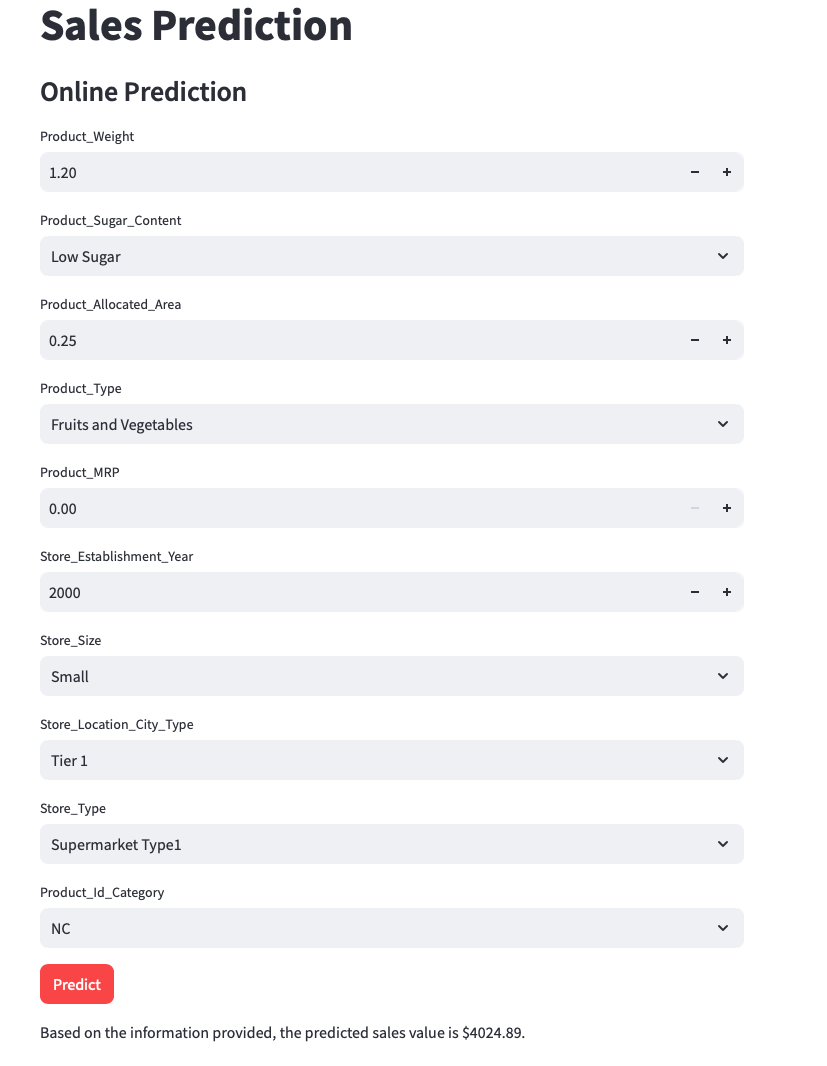

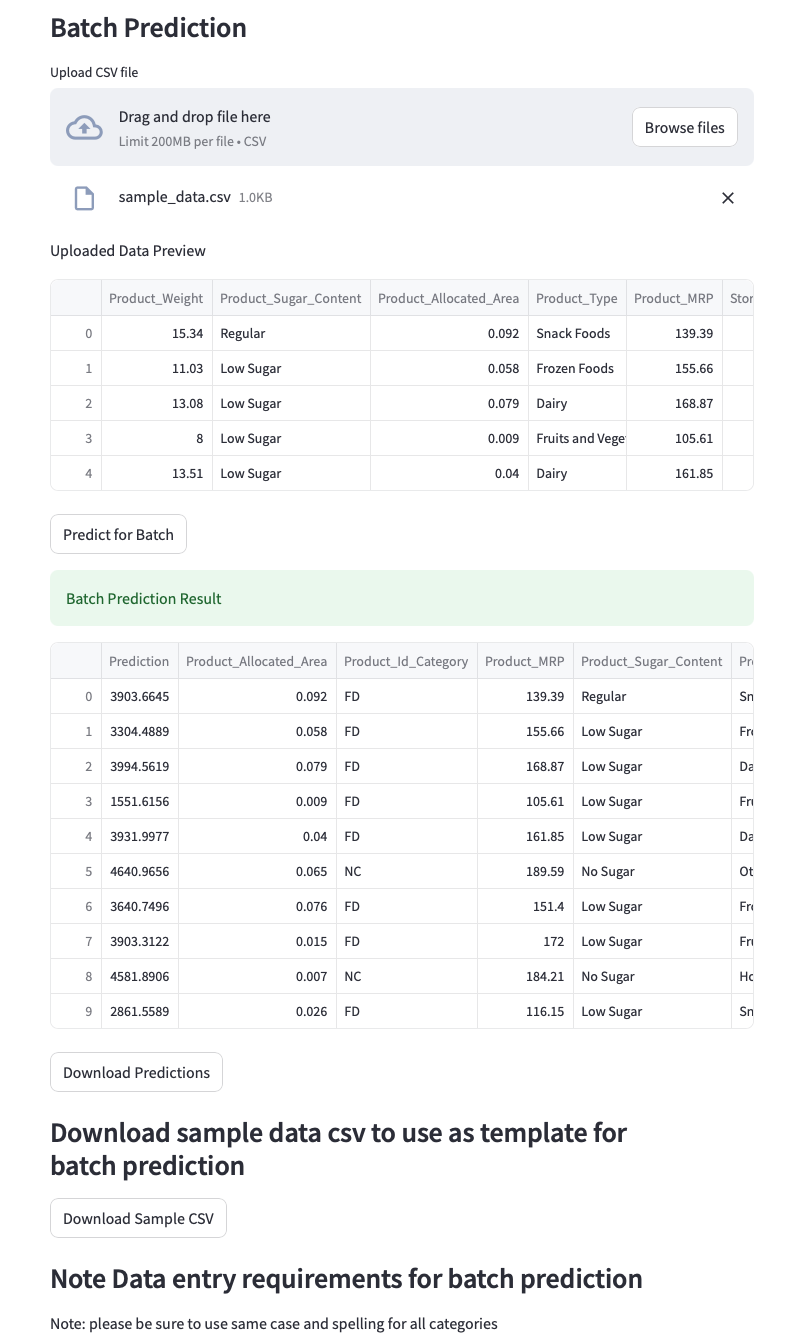